In [37]:
# Installation des librairies nécessaires
# Exécutez cette cellule en premier
import sys
!{sys.executable} -m pip install opencv-python numpy matplotlib pandas openpyxl

# Programmation Python M1 ESI
**Réalisé par :** Omar Lamari & Alexis Paris


---
# TP1 : La récursivité, le tri et la recherche dichotomique

## Exercice 1 : La récursivité

In [ ]:
# 1. Factorielle récursive Fact(N)
# Principe : N! = N × (N-1)! avec cas de base 0! = 1! = 1

def Fact(N):
    """Retourne la factorielle de N (entier naturel)."""
    if N == 0 or N == 1:       # Cas de base
        return 1
    return N * Fact(N - 1)     # Cas récursif


try:
    N = int(input("Entrez un entier naturel N : "))
    if N < 0:
        print("Erreur : N doit être un entier naturel (>= 0).")
    else:
        print(f"Fact({N}) = {Fact(N)}")
except ValueError:
    print("Erreur : veuillez saisir un nombre entier.")

In [ ]:
# 2. Suite de Fibonacci récursive Fibo(M)
# Principe : Fibo(M) = Fibo(M-1) + Fibo(M-2) avec Fibo(0)=0, Fibo(1)=1

def Fibo(M):
    """Retourne le M-ème terme de la suite de Fibonacci."""
    if M == 0:                     # Cas de base : F(0) = 0
        return 0
    elif M == 1:                   # Cas de base : F(1) = 1
        return 1
    return Fibo(M - 1) + Fibo(M - 2)  # Cas récursif


try:
    M = int(input("Entrez un entier naturel M : "))
    if M < 0:
        print("Erreur : M doit être un entier naturel (>= 0).")
    else:
        print(f"Fibo({M}) = {Fibo(M)}")
except ValueError:
    print("Erreur : veuillez saisir un nombre entier.")

In [ ]:
# 3. PGCD par algorithme d'Euclide (récursif)
# Principe : PGCD(A, B) = PGCD(B, A mod B) jusqu'à B = 0, alors PGCD = A

def PGCD(A, B):
    """Retourne le Plus Grand Commun Diviseur de A et B (A > B > 0)."""
    if B == 0:                     # Cas de base : PGCD(A, 0) = A
        return A
    return PGCD(B, A % B)          # Cas récursif : on remplace (A,B) par (B, A mod B)


try:
    A = int(input("Entrez le premier entier positif A : "))
    B = int(input("Entrez le deuxième entier positif B (B < A) : "))
    if A <= 0 or B <= 0:
        print("Erreur : A et B doivent être des entiers strictement positifs (> 0).")
    elif B >= A:
        print(f"Erreur : A doit être strictement supérieur à B (A={A}, B={B}).")
    else:
        print(f"PGCD({A}, {B}) = {PGCD(A, B)}")
except ValueError:
    print("Erreur : veuillez saisir des nombres entiers.")

## Exercice 2 : La recherche dichotomique

In [ ]:
# Recherche dichotomique dans une liste triée
# Principe : on divise l'espace de recherche en deux à chaque étape
# Complexité : O(log n) contre O(n) pour la recherche linéaire

def Dichotom(E, L):
    """Cherche E dans la liste triée L. Retourne E si trouvé, False sinon."""
    bas = 0                        # Borne inférieure de la zone de recherche
    haut = len(L) - 1              # Borne supérieure de la zone de recherche

    while bas <= haut:             # Tant que la zone n'est pas vide
        milieu = (bas + haut) // 2 # Indice central (division entière)

        if L[milieu] == E:         # Trouvé
            return E
        elif E < L[milieu]:        # E est dans la moitié gauche
            haut = milieu - 1
        else:                      # E est dans la moitié droite
            bas = milieu + 1

    return False                   # E absent de L


L = list(range(0, 51))             # Liste triée [0, 1, ..., 50]
print(f"Liste de recherche : {L}\n")

try:
    N = int(input("Entrez un nombre entier à rechercher dans la liste : "))
    resultat = Dichotom(N, L)
    if resultat is not False:
        print(f"Dichotom({N}, L)  {resultat}   Valeur trouvée dans la liste !")
    else:
        print(f"Dichotom({N}, L)  False   Valeur non trouvée dans la liste.")
except ValueError:
    print("Erreur : veuillez saisir un nombre entier.")

## Exercice 3 : Les algorithmes de tri

In [ ]:
import random

# Tri à bulle
# Principe : on fait remonter le plus grand élément à droite à chaque passe
# Complexité : O(n²) en pire cas, O(n) si déjà trié (optimisation par flag)

def Tri_Bulle(L):
    """Retourne une copie triée de L par l'algorithme du tri à bulle."""
    L_tri = L.copy()               # On ne modifie pas la liste originale
    n = len(L_tri)

    for i in range(n - 1):         # n-1 passes au maximum
        permutation = False        # Drapeau : y a-t-il eu une permutation ?

        for j in range(n - 1 - i): # Les i derniers éléments sont déjà à leur place
            if L_tri[j] > L_tri[j + 1]:
                L_tri[j], L_tri[j + 1] = L_tri[j + 1], L_tri[j]  # Échange
                permutation = True

        if not permutation:        # Optimisation : liste déjà triée  on arrête
            break

    return L_tri


try:
    taille = int(input("Entrez la taille de la liste à trier (entre 2 et 40) : "))
    if taille < 2:
        print("Erreur : la taille doit être >= 2.")
    elif taille > 40:
        print("Erreur : la taille doit être <= 40.")
    else:
        L = random.sample(range(1, 41), taille)
        print(f"Avant : {L}")
        print(f"Après : {Tri_Bulle(L)}")
except ValueError:
    print("Erreur : veuillez saisir un nombre entier.")

In [ ]:
# Tri par sélection
# Principe : on cherche le minimum de la partie non triée et on le place en tête
# Complexité : O(n²) — nombre de comparaisons fixe, peu d'échanges

def Tri_Select(L):
    """Retourne une copie triée de L par l'algorithme du tri par sélection."""
    L_tri = L.copy()
    n = len(L_tri)

    for i in range(n - 1):             # i : début de la partie non triée
        indice_min = i                 # On suppose que L_tri[i] est le minimum
        for j in range(i + 1, n):     # Recherche du vrai minimum dans [i+1..n-1]
            if L_tri[j] < L_tri[indice_min]:
                indice_min = j

        if indice_min != i:            # Échange uniquement si nécessaire
            L_tri[i], L_tri[indice_min] = L_tri[indice_min], L_tri[i]

    return L_tri


try:
    taille = int(input("Entrez la taille de la liste à trier (entre 2 et 40) : "))
    if taille < 2:
        print("Erreur : la taille doit être >= 2.")
    elif taille > 40:
        print("Erreur : la taille doit être <= 40.")
    else:
        L = random.sample(range(1, 41), taille)
        print(f"Avant : {L}")
        print(f"Après : {Tri_Select(L)}")
except ValueError:
    print("Erreur : veuillez saisir un nombre entier.")

In [ ]:
# Tri par fusion (Merge Sort)
# Principe diviser pour régner : on divise, on trie chaque moitié récursivement, on fusionne
# Complexité : O(n log n) — plus efficace que bulle/sélection pour grandes listes

def _Fusionner(gauche, droite):
    """Fusionne deux listes triées en une seule liste triée."""
    resultat = []
    i = j = 0

    # On compare les têtes des deux listes et on insère le plus petit
    while i < len(gauche) and j < len(droite):
        if gauche[i] <= droite[j]:
            resultat.append(gauche[i])
            i += 1
        else:
            resultat.append(droite[j])
            j += 1

    # On ajoute les éléments restants (une seule liste peut en avoir)
    resultat.extend(gauche[i:])
    resultat.extend(droite[j:])
    return resultat


def Tri_Fusion(L):
    """Retourne une copie triée de L par l'algorithme du tri par fusion (récursif)."""
    n = len(L)

    if n <= 1:                         # Cas de base : liste de 0 ou 1 élément déjà triée
        return L.copy()

    milieu = n // 2                    # Découpage en deux moitiés
    gauche = Tri_Fusion(L[:milieu])    # Tri récursif moitié gauche
    droite = Tri_Fusion(L[milieu:])    # Tri récursif moitié droite

    return _Fusionner(gauche, droite)  # Fusion des deux moitiés triées


try:
    taille = int(input("Entrez la taille de la liste à trier (entre 2 et 40) : "))
    if taille < 2:
        print("Erreur : la taille doit être >= 2.")
    elif taille > 40:
        print("Erreur : la taille doit être <= 40.")
    else:
        L = random.sample(range(1, 41), taille)
        print(f"Avant : {L}")
        print(f"Après : {Tri_Fusion(L)}")
except ValueError:
    print("Erreur : veuillez saisir un nombre entier.")

---
# TP3 : La programmation orientée objets

## Exercice 1 : Classe `Personne`

In [70]:
class Personne:
    """Représente un personnage positionné dans un espace 2D."""

    def __init__(self):
        # Attributs par défaut : nom et position initiale
        self.nom = "Jule"
        self.x = 1
        self.y = 3

    def __repr__(self):
        """Affichage : nom et position [x, y]."""
        return f"{self.nom} est à la position [{self.x}, {self.y}]"

    def avancer_d(self, pas):
        """Déplacement vers la droite (+x)."""
        self.x += pas

    def avancer_g(self, pas):
        """Déplacement vers la gauche (-x)."""
        self.x -= pas

    def avancer_h(self, pas):
        """Déplacement vers le haut (+y)."""
        self.y += pas

    def avancer_b(self, pas):
        """Déplacement vers le bas (-y)."""
        self.y -= pas

In [71]:
# Test : P1  position finale [3, 0]
P1 = Personne()
P1.nom = "Omar"
P1.x, P1.y = 0, 0
P1.avancer_d(5)   # x = 5
P1.avancer_h(2)   # y = 2
P1.avancer_g(2)   # x = 3
P1.avancer_b(2)   # y = 0
print(P1)

# Test : P2  position finale [2, -3]
P2 = Personne()
P2.nom = "Alexis"
P2.x, P2.y = 0, 0
P2.avancer_d(7)   # x = 7
P2.avancer_h(3)   # y = 3
P2.avancer_g(5)   # x = 2
P2.avancer_b(6)   # y = -3
print(P2)

Omar est à la position [3, 0]
Alexis est à la position [2, -3]


## Exercice 2 : Classes `Etudiant`, `Cadre`, `Fonctionnaire`

In [72]:
class Etudiant(Personne):
    """Représente un étudiant, hérite de Personne."""

    def __init__(self):
        super().__init__()
        self.universite = "ube"    # Université par défaut
        self.compte = 100          # Solde bancaire initial

    def __repr__(self):
        return (f"{self.nom} est étudiant à l' {self.universite} "
                f"et a sur son compte {self.compte} euros.")

    def domaine(self, sp, niv):
        """Définit la spécialité et le niveau d'études."""
        self.sp = sp
        self.niv = niv

    def depenses(self):
        """Débite 50 € du compte à chaque achat."""
        self.compte -= 50

In [73]:
class Cadre(Etudiant):
    """Représente un cadre, hérite d'Etudiant (et donc de Personne)."""

    def __init__(self):
        super().__init__()
        self.entreprise = "la poste"  # Entreprise par défaut
        self.compte = 2000            # Solde plus élevé qu'un étudiant

    def __repr__(self):
        return (f"{self.nom} est cadre a {self.entreprise} "
                f"et a sur son compte {self.compte} euros.")

    def depenses(self):
        """Débite 500 € du compte à chaque achat."""
        self.compte -= 500

    def salaire(self):
        """Verse un salaire mensuel de 3000 €."""
        self.compte += 3000

In [74]:
class Fonctionnaire(Personne):
    """Représente un fonctionnaire, hérite de Personne."""

    def __init__(self):
        super().__init__()
        self.entreprise = "la poste"  # Entreprise par défaut
        self.nom = "Rayane"           # Surcharge du nom par défaut de Personne
        self.compte = 1000            # Solde initial

    def __repr__(self):
        return (f"{self.nom} est fonctionnaire a {self.entreprise} "
                f"et a sur son compte {self.compte} euros.")

    def depenses(self):
        """Débite 200 € du compte à chaque achat."""
        self.compte -= 200

    def salaire(self):
        """Verse un salaire mensuel de 1800 €."""
        self.compte += 1800

In [75]:
# Test Etudiant
E1 = Etudiant()
E1.nom = "Jules"
print(E1)
E1.domaine("TSI", "Master 1")
E1.depenses()
print(f"{E1.sp} {E1.niv}\nStatut du compte : {E1.compte} euros.")

# Test Cadre
C1 = Cadre()
C1.nom = "César"
C1.depenses()   # 2000 - 500 = 1500
C1.salaire()    # 1500 + 3000 = 4500
print(C1)

# Test Fonctionnaire
F1 = Fonctionnaire()
F1.depenses()   # 1000 - 200 = 800
F1.salaire()    # 800 + 1800 = 2600
print(F1)

Jules est étudiant à l' ube et a sur son compte 100 euros.
TSI Master 1
Statut du compte : 50 euros.
César est cadre a la poste et a sur son compte 4500 euros.
Rayane est fonctionnaire a la poste et a sur son compte 2600 euros.


## Exercice 3 : Héritage multiple — Classe `Retraité`

In [77]:
class Retraité(Cadre, Fonctionnaire):
    """
    Représente un retraité, ancien cadre ou fonctionnaire.
    Hérite de Cadre ET Fonctionnaire (héritage multiple).
    MRO Python : Retraité  Cadre  Etudiant  Fonctionnaire  Personne
    """

    def __init__(self, categorie):
        super().__init__()
        self.compte = 5000         # Solde initial à la retraite

        # Validation et assignation de la catégorie
        if categorie == 0:
            self.categorie = "cadre"
        elif categorie == 1:
            self.categorie = "fonctionnaire simple"
        else:
            raise ValueError("Veuillez saisir 0 (cadre) ou 1 (fonctionnaire simple).")

    def __repr__(self):
        return (f"{self.nom} est retraité(e), elle était {self.categorie} "
                f"et a sur son compte {self.compte:.2f} euros.")

    def depenses(self):
        """Débite 150 € du compte à chaque achat."""
        self.compte -= 150

    def pension(self, cat):
        """
        Verse la pension mensuelle : 80% de l'ancien salaire.
        cat=0  ancien cadre (salaire 3000 €), cat=1  fonctionnaire (salaire 1800 €).
        """
        if cat == 0:
            self.compte += 0.8 * 3000   # Pension cadre : 2400 €/mois
        elif cat == 1:
            self.compte += 0.8 * 1800   # Pension fonctionnaire : 1440 €/mois
        else:
            raise ValueError("Veuillez saisir 0 (cadre) ou 1 (fonctionnaire simple).")

In [78]:
# R1 : ancienne cadre
# Épargne sur 30 ans : 10% × 3000 €/mois × 12 mois × 30 ans = 300 × 12 × 30
R1 = Retraité(0)
R1.nom = "Alice"
R1.pension(0)               # Année 1
R1.pension(0)               # Année 2
R1.pension(0)               # Année 3
R1.compte += 300 * 12 * 30 # Épargne cumulée sur la carrière
print(R1)

# R2 : ancien fonctionnaire
# Épargne sur 30 ans : 10% × 1800 €/mois × 12 mois × 30 ans = 180 × 12 × 30
R2 = Retraité(1)
R2.nom = "Roger"
R2.pension(1)
R2.pension(1)
R2.pension(1)
R2.compte += 180 * 12 * 30
print(R2)

Alice est retraité(e), elle était cadre et a sur son compte 120200.00 euros.
Roger est retraité(e), elle était fonctionnaire simple et a sur son compte 74120.00 euros.


---
# TP4 : Traitement d'une image numérique

> L'image utilisée est `barbara_ng.png` (512×512 pixels, niveaux de gris, 8 bits).  
> Valeur des pixels : 0 = noir, 255 = blanc.

## Imports

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Fonctions de traitement

In [39]:
def Lire_Image(chemin):
    """
    Lit une image en niveaux de gris depuis un fichier PNG.
    Retourne le tableau NumPy 2D (512×512).
    """
    image = cv2.imread(chemin, 0)        # 0 = flag OpenCV pour niveaux de gris
    if image is None:
        raise FileNotFoundError(f"Image introuvable : {chemin}")
    hauteur, largeur = image.shape       # Dimensions de l'image
    print(f"Image chargée : {largeur}×{hauteur} pixels")
    print(f"Vecteur aplati : {image.flatten()}")  # Affichage 1D
    return image

In [40]:

def Get_Pixel(img, l, c):
    """
    Retourne la valeur du pixel à la ligne l, colonne c.
    Convention OpenCV : img[ligne, colonne] = img[y, x]
    """
    if not (0 <= l < img.shape[0] and 0 <= c < img.shape[1]):
        raise IndexError(f"Position ({l}, {c}) hors de l'image {img.shape}")
    return int(img[l, c])


def Set_Pixel(img, l, c, valeur):
    """
    Modifie la valeur du pixel à la ligne l, colonne c.
    La valeur est clampée dans [0, 255].
    Retourne l'image modifiée (copie).
    """
    img_modif = img.copy()                        # On ne modifie pas l'original
    if not (0 <= l < img.shape[0] and 0 <= c < img.shape[1]):
        raise IndexError(f"Position ({l}, {c}) hors de l'image {img.shape}")
    img_modif[l, c] = np.clip(valeur, 0, 255)     # Clampage dans [0, 255]
    return img_modif

In [41]:
def Calcul_Histo(img):
    """
    Calcule l'histogramme des niveaux de gris d'une image.
    Retourne un tableau de 256 entiers : histo[i] = nb de pixels de couleur i.
    """
    # cv2.calcHist : [image], [canal 0], pas de masque, [256 bins], plage [0,256]
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    return hist


def Affiche_Histo(hist):
    """
    Affiche l'histogramme des niveaux de gris dans une figure matplotlib.
    """
    plt.figure(figsize=(8, 4))             # Taille de la figure
    plt.plot(hist, color='steelblue')      # Courbe de l'histogramme
    plt.title("Histogramme des niveaux de gris")
    plt.xlabel("Niveau de gris (0=noir, 255=blanc)")
    plt.ylabel("Nombre de pixels")
    plt.xlim([0, 256])                     # Axe X borné à [0, 255]
    plt.grid(alpha=0.3)                    # Grille légère
    plt.tight_layout()
    plt.show()

In [42]:

def Binarise_Image(img, seuil):
    """
    Binarise une image en niveaux de gris selon un seuil.
    pixel < seuil   0 (noir)
    pixel >= seuil  255 (blanc)
    Retourne un nouveau tableau de même taille.
    """
    # np.where : sélection vectorisée, bien plus rapide qu'une boucle
    img_bin = np.where(img >= seuil, 255, 0).astype(np.uint8)
    return img_bin

In [43]:

def Sauvegarde_Image(img, nom_fichier):
    """
    Sauvegarde un tableau d'image dans un fichier PNG.
    Retourne True si succès, False sinon.
    """
    # On s'assure de l'extension .png
    if not nom_fichier.lower().endswith('.png'):
        nom_fichier += '.png'
    succes = cv2.imwrite(nom_fichier, img)
    if succes:
        print(f"Image sauvegardée  '{nom_fichier}'")
    else:
        print(f"Erreur : impossible de sauvegarder '{nom_fichier}'")
    return succes

In [66]:
import matplotlib.patches as patches

def Zoom_Zone(img, l, c, f, afficher=True):
    """
   Zoome sur une zone carrée de 11×11 pixels (rayon=5) autour du pixel (l, c).
   Chaque pixel est répété f×f fois.
   Paramètres :
       img       : tableau image source
       l, c      : ligne et colonne du pixel central
       f         : facteur de zoom (entier >= 1)
       afficher  : si True, affiche la zone zoomée (défaut : True)
            
    Retourne le tableau de la zone zoomée.
    """
    rayon = 5
    h, w = img.shape

    l_debut = max(0, l - rayon)
    l_fin   = min(h, l + rayon + 1)
    c_debut = max(0, c - rayon)
    c_fin   = min(w, c + rayon + 1)

    zone       = img[l_debut:l_fin, c_debut:c_fin]        # 11×11
    zone_zoomee = np.repeat(np.repeat(zone, f, axis=0),   # 44×44 si f=4
                             f, axis=1)

    if afficher:
        # Taille des subplots proportionnelle : droite = f× plus grande que gauche
        fig, axes = plt.subplots(
            1, 2,
            figsize=(12, 5),
            gridspec_kw={'width_ratios': [w / (zone_zoomee.shape[1]), 1]}
        )

        # Gauche : image complète avec rectangle rouge sur la zone
        axes[0].imshow(img, cmap='gray', vmin=0, vmax=255)
        rect = patches.Rectangle(
            (c_debut - 0.5, l_debut - 0.5),
            zone.shape[1], zone.shape[0],
            linewidth=2, edgecolor='red', facecolor='none'
        )
        axes[0].add_patch(rect)
        axes[0].set_title("Image originale (zone en rouge)")
        axes[0].axis('off')

        # Droite : zone zoomée, interpolation='nearest' pour voir les blocs
        axes[1].imshow(zone_zoomee, cmap='gray', vmin=0, vmax=255,
                       interpolation='nearest')
        axes[1].set_title(
            f"Zone zoomée ×{f}"
        )
        axes[1].axis('off')

        plt.suptitle(f"Zoom ×{f} centré sur le pixel ({l}, {c})", fontsize=13)
        plt.tight_layout()
        plt.show()

    return zone_zoomee

In [64]:

def Filtre_Image(img, filtre):
    """
    Applique un filtre (matrice carrée de taille impaire) sur l'image.
    Principe : convolution — pour chaque pixel, on multiplie son voisinage
               par le filtre et on somme pour obtenir la nouvelle valeur.
    Les bords sont gérés par réplication (mode 'edge').
    
    Paramètres :
        img    : tableau image source (niveaux de gris)
        filtre : matrice NumPy carrée de taille impaire (ex : 3×3)
    Retourne l'image filtrée (uint8, valeurs dans [0, 255]).
    
    Filtres disponibles :
        Gauss = [[0, 0.1, 0], [0.1, 0.6, 0.1], [0, 0.1, 0]]   lissage
        Sobel = [[0, -0.5, 0], [-0.5, 0, 0.5], [0, 0.5, 0]]   détection contours
    """
    h, w = img.shape
    ksize = filtre.shape[0]    # Taille du noyau (ex : 3 pour un filtre 3×3)
    pad = ksize // 2           # Marge de zéro-rembourrage (ex : 1 pour 3×3)

    # On rembourre l'image pour traiter les pixels de bord (mode 'edge' = réplication)
    img_pad = np.pad(img, pad, mode='edge').astype(np.float64)

    img_filtre = np.zeros((h, w), dtype=np.float64)

    # Convolution : pour chaque pixel (i, j), on applique le filtre sur son voisinage
    for i in range(h):
        for j in range(w):
            region = img_pad[i:i + ksize, j:j + ksize]   # Voisinage ksize×ksize
            img_filtre[i, j] = np.sum(region * filtre)    # Produit élément par élément + somme

    # On clampe les valeurs dans [0, 255] et on repasse en entiers non signés
    img_filtre = np.clip(img_filtre, 0, 255).astype(np.uint8)
    return img_filtre

## Programme principal TP4

Image chargée : 512×512 pixels
Vecteur aplati : [175 169 164 ... 104 101  94]


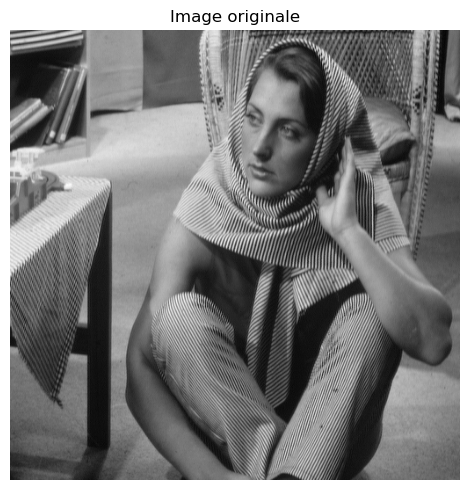

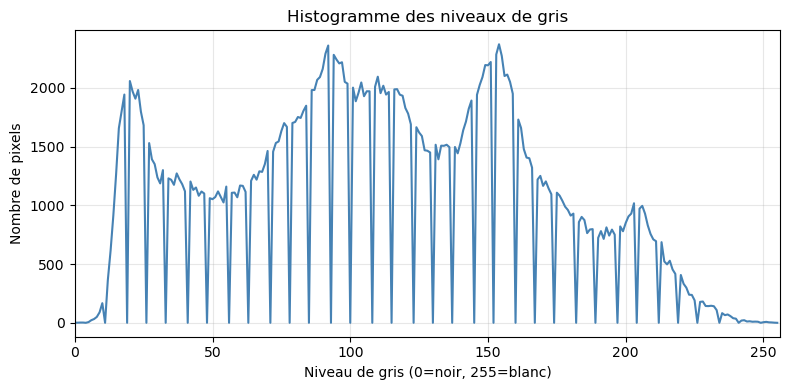

Pixel (3, 9) original : 116
Pixel (3, 9) après Set_Pixel à 0 : 0


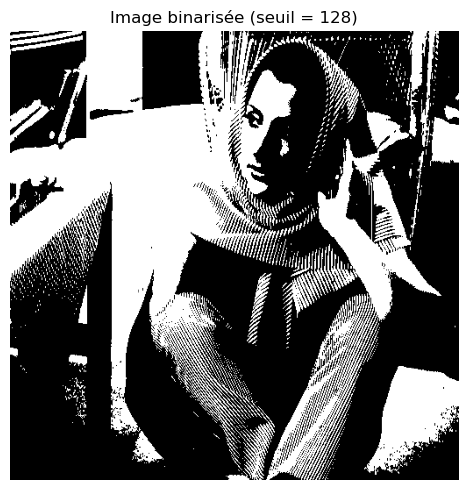

Image sauvegardée  'barbara_binarisee.png'


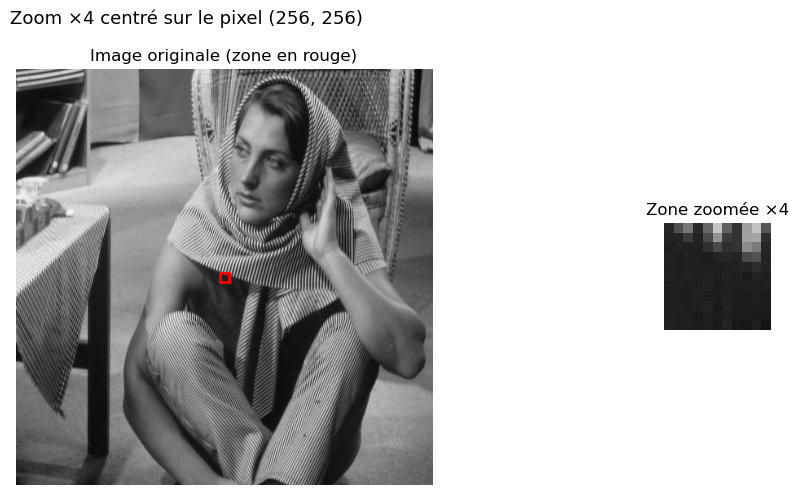

Pixel (3, 9) après filtre Gauss : 116


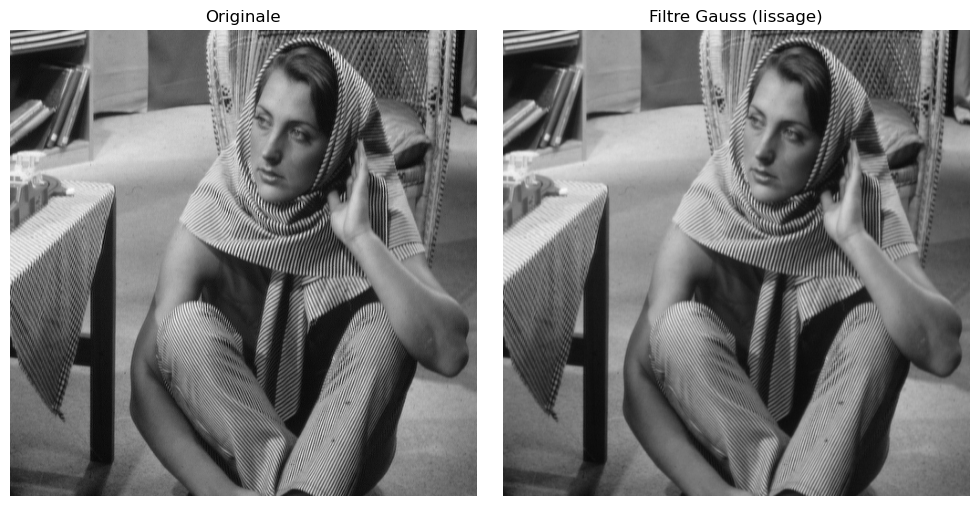

Image sauvegardée  'barbara_gauss.png'


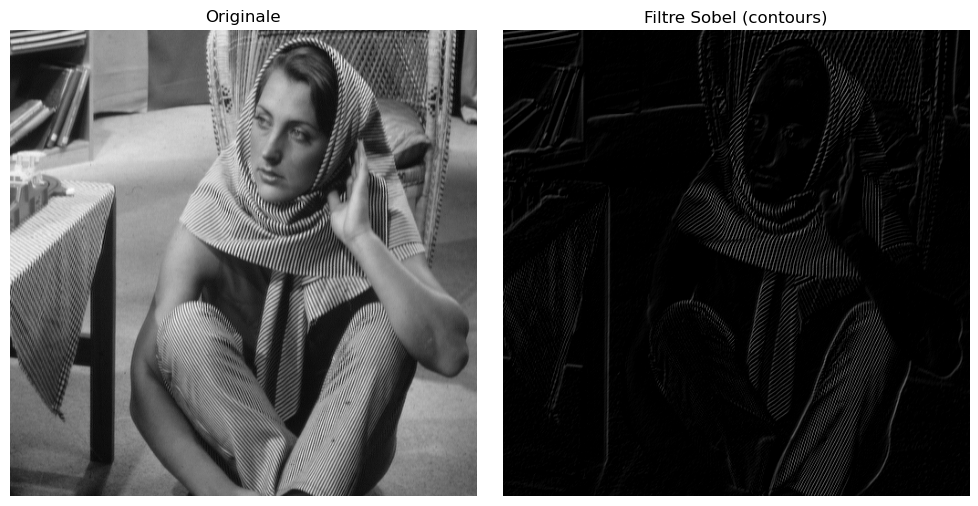

Image sauvegardée  'barbara_sobel.png'


In [65]:
# Filtres définis dans l'énoncé
FILTRE_GAUSS = np.array([[0,    0.1, 0  ],
                          [0.1,  0.6, 0.1],
                          [0,    0.1, 0  ]])

FILTRE_SOBEL = np.array([[0,   -0.5, 0  ],
                          [-0.5, 0,   0.5],
                          [0,    0.5, 0  ]])


def main_tp4(path="barbara_ng.png"):
    # 1. Chargement de l'image
    img = Lire_Image(path)

    # 2. Affichage de l'image originale
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title("Image originale")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 3. Calcul et affichage de l'histogramme
    hist = Calcul_Histo(img)
    Affiche_Histo(hist)

    # 4. Lecture et modification d'un pixel
    val = Get_Pixel(img, 3, 9)
    print(f"Pixel (3, 9) original : {val}")
    img_modif = Set_Pixel(img, 3, 9, 0)   # On met ce pixel à 0 (noir)
    print(f"Pixel (3, 9) après Set_Pixel à 0 : {Get_Pixel(img_modif, 3, 9)}")

    # 5. Binarisation (seuil = 128)
    img_bin = Binarise_Image(img, seuil=128)
    plt.figure(figsize=(5, 5))
    plt.imshow(img_bin, cmap='gray', vmin=0, vmax=255)
    plt.title("Image binarisée (seuil = 128)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    Sauvegarde_Image(img_bin, "barbara_binarisee")

    # 6. Zoom sur un point d'intérêt (centre : ligne 256, colonne 256), facteur ×4
    img_zoom = Zoom_Zone(img, l=256, c=256, f=4, afficher=True)

    # 7. Filtre de Gauss (lissage)
    img_gauss = Filtre_Image(img, FILTRE_GAUSS)
    print(f"Pixel (3, 9) après filtre Gauss : {Get_Pixel(img_gauss, 3, 9)}")
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title("Originale")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img_gauss, cmap='gray', vmin=0, vmax=255)
    plt.title("Filtre Gauss (lissage)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    Sauvegarde_Image(img_gauss, "barbara_gauss")

    # 8. Filtre de Sobel (détection de contours)
    img_sobel = Filtre_Image(img, FILTRE_SOBEL)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)
    plt.title("Originale")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img_sobel, cmap='gray', vmin=0, vmax=255)
    plt.title("Filtre Sobel (contours)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    Sauvegarde_Image(img_sobel, "barbara_sobel")


main_tp4("barbara_ng.png")

---
# TP5 : Analyse de données à partir d'un fichier tableur

> Le fichier utilisé est `individus.xlsx` (19 individus, 6 colonnes, valeurs manquantes).

## Imports

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Définition des fonctions

In [27]:
def Lire_Donnees():
    """
    Demande un nom de fichier à l'utilisateur et charge le fichier Excel (.xlsx)
    dans un DataFrame Pandas. Retourne le DataFrame.
    """
    nomFichier = input("Saisissez le nom du fichier à lire (sans l'extension) : ")
    df = pd.read_excel(nomFichier + ".xlsx")
    return df

In [28]:
def Nettoyer_Donnees(df):
    """
    Nettoie un DataFrame :
      1. Supprime les lignes entièrement vides
      2. Supprime les colonnes entièrement vides
      3. Convertit les colonnes qui contiennent des valeurs numériques en float
         (nécessaire quand la colonne est de type objet à cause des '?'NaN)
      4. Remplace les NaN numériques par la moyenne de leur colonne
      5. Remplace les NaN restants (chaînes) par 'Inconnu'
    Retourne le DataFrame nettoyé.
    """
    df = df.copy()
    df = df.dropna(how='all', axis=0)   # Suppression lignes entièrement vides
    df = df.dropna(how='all', axis=1)   # Suppression colonnes entièrement vides

    # Sans ça, les colonnes de type objet (ex : '170', NaN, '163') ne sont pas
    # traitées par fillna(df.mean(numeric_only=True))  les NaN restent à 'Inconnu'
    for col in df.columns:
        converti = pd.to_numeric(df[col], errors='coerce')   # Tente la conversion numérique
        if converti.notna().sum() > 0:                        # Si au moins une valeur est numérique
            df[col] = converti                                # On remplace la colonne

    # Remplacement des NaN numériques par la moyenne de leur colonne
    df = df.fillna(df.mean(numeric_only=True))
    # Remplacement des NaN restants (colonnes texte) par 'Inconnu'
    df = df.fillna("Inconnu")

    return df

In [29]:
def Ajouter_Colonne_IMC(df):
    """
    Ajoute une colonne 'IMC' calculée d'après la formule :
    IMC = Poids (kg) / (Taille (m))²
    Les colonnes 'Taille (cm)' et 'Poids (Kg)' doivent exister.
    Retourne le DataFrame avec la nouvelle colonne.
    """
    df = df.copy()
    if 'Taille (cm)' in df.columns and 'Poids (Kg)' in df.columns:
        taille_m = pd.to_numeric(df['Taille (cm)'], errors='coerce') / 100  # cm  m
        poids    = pd.to_numeric(df['Poids (Kg)'],  errors='coerce')
        df['IMC'] = (poids / taille_m ** 2).round(2)  # Arrondi à 2 décimales
    else:
        print("Erreur : colonnes 'Taille (cm)' ou 'Poids (Kg)' introuvables.")
    return df

In [30]:
def Filtrer_df(df, nom_colonne, valeur):
    """
    Retourne un sous-DataFrame contenant uniquement les lignes
    dont la colonne 'nom_colonne' est égale à 'valeur'.
    """
    return df[df[nom_colonne] == valeur].copy()

In [31]:
def Fusionner_Donnees(df_a, df_b):
    """
    Fusionne deux DataFrames côte à côte (axe des colonnes).
    Les deux DataFrames doivent avoir le même index.
    Retourne le DataFrame fusionné.
    """
    return pd.concat([df_a, df_b], axis=1)

In [32]:
def Statistiques_df(df, colonne):
    """
    Calcule les statistiques de base (moyenne, médiane, min, max, écart-type)
    pour la colonne numérique spécifiée.
    Retourne un DataFrame à une ligne avec les résultats.
    """
    if colonne not in df.columns:
        print(f"Erreur : colonne '{colonne}' introuvable.")
        return pd.DataFrame()

    s = pd.to_numeric(df[colonne], errors='coerce').dropna()  # Valeurs numériques uniquement

    return pd.DataFrame({
        'Colonne'    : [colonne],
        'Moyenne'    : [round(s.mean(),   2)],
        'Médiane'    : [round(s.median(), 2)],
        'Minimum'    : [round(s.min(),    2)],
        'Maximum'    : [round(s.max(),    2)],
        'Écart-type' : [round(s.std(),    2)],
        'Nb valeurs' : [len(s)],
    })

In [33]:
def Normaliser_Donnees(df):
    """
    Normalise toutes les colonnes numériques du DataFrame selon la formule :
    x_norm = (x - x_min) / (x_max - x_min)   valeurs dans [0, 1]
    Si x_max = x_min (colonne constante), on met 0 pour éviter la division par zéro.
    Retourne le DataFrame normalisé (les colonnes texte sont conservées).
    """
    df_n = df.copy()
    cols_num = df_n.select_dtypes(include=[np.number]).columns  # Colonnes numériques uniquement

    for col in cols_num:
        x_min, x_max = df_n[col].min(), df_n[col].max()
        if x_max != x_min:                                      # Évite la division par zéro
            df_n[col] = ((df_n[col] - x_min) / (x_max - x_min)).round(4)
        else:
            df_n[col] = 0.0                                     # Colonne constante  tout à 0

    print(f"Normalisation appliquée sur {len(cols_num)} colonnes : {list(cols_num)}")
    return df_n

In [34]:
def Afficher_Distribution(df, colonne):
    """
    Trace l'histogramme de distribution d'une colonne numérique.
    Ajoute une ligne verticale pour la moyenne et la médiane.
    """
    if colonne not in df.columns:
        print(f"Erreur : colonne '{colonne}' introuvable.")
        return

    s = pd.to_numeric(df[colonne], errors='coerce').dropna()

    plt.figure(figsize=(8, 4))
    s.plot(kind='hist', bins=10, color='steelblue', edgecolor='white', alpha=0.8,
           title=f'Distribution de {colonne}')

    # Ajout des lignes moyenne / médiane pour faciliter la lecture
    plt.axvline(s.mean(),   color='red',    linestyle='--', label=f'Moyenne : {s.mean():.2f}')
    plt.axvline(s.median(), color='orange', linestyle='--', label=f'Médiane : {s.median():.2f}')

    plt.xlabel(colonne)
    plt.ylabel("Nb d'individus")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [35]:
def Exporter_Donnees(df, nom_fichier, separateur=';'):
    """
    Exporte un DataFrame dans un fichier CSV.
    Le séparateur par défaut est ';' (compatible Excel FR).
    L'encodage utf-8-sig garantit l'affichage des accents dans Excel.
    """
    if not nom_fichier.endswith('.csv'):
        nom_fichier += '.csv'

    df.to_csv(nom_fichier, sep=separateur, index=True, encoding='utf-8-sig')
    print(f"Exporté  '{nom_fichier}' ({df.shape[0]} lignes × {df.shape[1]} colonnes)")

## Programme principal TP5

Saisissez le nom du fichier à lire (sans l'extension) :  individus


=== 4 premières lignes ===
   Unnamed: 0 Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  \
0         NaN      Louis     Julien          M        170         70   
1         NaN      Ellen      Sarah          F        159         61   
2         NaN       Bart     Michel          M        178         76   
3         NaN     Norton       Adam          M        NaN         84   

  Unnamed: 6  
0         38  
1         26  
2         56  
3         35  

=== 3 dernières lignes ===
    Unnamed: 0 Unnamed: 1 Unnamed: 2 Unnamed: 3 Unnamed: 4 Unnamed: 5  \
16         NaN     Gerard      Bruno          M        176          ?   
17         NaN      Robin        Luc          M        189        NaN   
18         NaN     Garcia       Jade          F        NaN         56   

   Unnamed: 6  
16        NaN  
17         19  
18         48  

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 7 columns):
 #   Column      N

C:\Users\Omar\AppData\Local\Temp\ipykernel_5148\3742853806.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1.replace('?', np.nan, inplace=True)


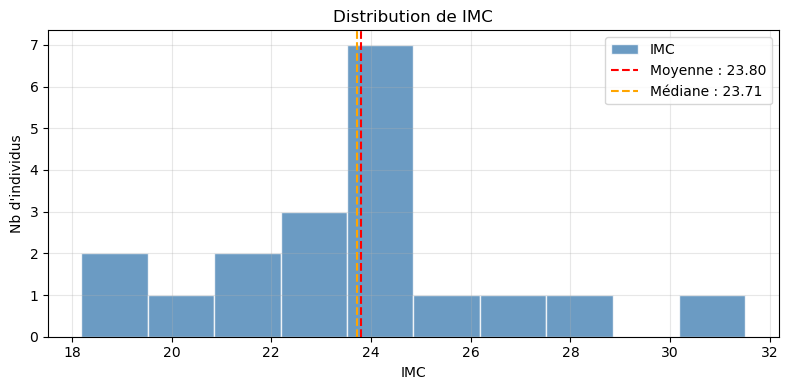

Exporté  'df2_nettoye.csv' (19 lignes × 6 colonnes)
Exporté  'df3_avec_IMC.csv' (19 lignes × 7 colonnes)
Exporté  'df4_masculin.csv' (10 lignes × 7 colonnes)
Exporté  'df6_fusionne.csv' (19 lignes × 8 colonnes)
Exporté  'df8_normalise.csv' (19 lignes × 8 colonnes)

Tous les fichiers CSV ont été générés.


In [36]:
def main_tp5():
    #  Étape 1 : Lecture 
    df1 = Lire_Donnees()                     # Saisir 'individus' quand demandé
    print("=== 4 premières lignes ===")
    print(df1.head(4))
    print("\n=== 3 dernières lignes ===")
    print(df1.tail(3))
    print("\n=== Informations générales ===")
    print(df1.info())

    # Remplacement des '?' par NaN
    df1.replace('?', np.nan, inplace=True)
    print("\n=== Valeurs manquantes par colonne ===")
    print(df1.isna().sum())
    print(f"Total valeurs manquantes : {df1.isna().sum().sum()}")
    print("\n=== Lignes incomplètes ===")
    print(df1[df1.isna().any(axis=1)])

    #  Étape 2 : Nettoyage 
    df2 = Nettoyer_Donnees(df1)
    # Renommage des index de lignes et des colonnes
    df2.index   = ["L" + str(i + 1) for i in range(len(df2))]
    df2.columns = ['Nom', 'Prénom', 'Sexe', 'Taille (cm)', 'Poids (Kg)', 'Age (ans)']
    print("\n=== df2 nettoyé ===")
    print(df2)

    #  Étape 3 : Ajout de l'IMC 
    df3 = Ajouter_Colonne_IMC(df2)
    print("\n=== df3 avec colonne IMC ===")
    print(df3)

    #  Étape 4 : Filtrage (hommes uniquement) 
    df4 = Filtrer_df(df3, 'Sexe', 'M')
    print("\n=== df4 individus masculins ===")
    print(df4)

    #  Étape 5 : Fusion avec activités sportives 
    sports = ['Football', 'Tennis', 'Natation', 'Cyclisme', 'Running',
              'Basketball', 'Yoga', 'Escalade', 'Boxe', 'Badminton']

    # df5 : activités pour les masculins seulement (même index que df4)
    df5 = pd.DataFrame(
        {'Activité sportive': [sports[i % len(sports)] for i in range(len(df4))]},
        index=df4.index
    )
    print("\n=== df5 activités (hommes) ===")
    print(df5)

    # df5_all : activités pour tous les individus de df3
    df5_all = pd.DataFrame(
        {'Activité sportive': [sports[i % len(sports)] for i in range(len(df3))]},
        index=df3.index
    )

    # df6 : fusion df3 + activités
    df6 = Fusionner_Donnees(df3, df5_all)
    print("\n=== df6 fusionné ===")
    print(df6)

    #  Étape 6 : Statistiques 
    df7 = Statistiques_df(df6, 'Age (ans)')
    print("\n=== df7 statistiques Age ===")
    print(df7)

    #  Étape 7 : Normalisation 
    df8 = Normaliser_Donnees(df6)
    print("\n=== df8 normalisé ===")
    print(df8)

    #  Étape 8 : Distribution IMC 
    Afficher_Distribution(df6, 'IMC')

    #  Étape 9 : Export CSV 
    Exporter_Donnees(df2, 'df2_nettoye')
    Exporter_Donnees(df3, 'df3_avec_IMC')
    Exporter_Donnees(df4, 'df4_masculin')
    Exporter_Donnees(df6, 'df6_fusionne')
    Exporter_Donnees(df8, 'df8_normalise')
    print("\nTous les fichiers CSV ont été générés.")


main_tp5()